# BASELINE MODEL 1 :


# STEP 1 : IMPORT LIBRARIES 

In [1]:
%pip install vaderSentiment 
%pip install spacy


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [29]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
 
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# STEP 2 — LOAD DATA

In [5]:
DATA_PATH = 'C:/Users/TANZEEM/Desktop/ed-feed project/datasetpreprocessing/Imbalance correction/balanced_edufeed_dataset_FINAL.csv'
df = pd.read_csv(DATA_PATH)
print(f"  Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns: {list(df.columns)}")
print()

  Shape  : 35421 rows × 62 columns
  Columns: ['professor_name', 'school_name', 'department_name', 'local_name', 'state_name', 'year_since_first_review', 'star_rating', 'take_again', 'diff_index', 'tag_professor', 'num_student', 'post_date', 'name_onlines', 'name_not_onlines', 'student_star', 'student_difficult', 'attence', 'for_credits', 'would_take_agains', 'grades', 'help_useful', 'help_not_useful', 'comments', 'word_comment', 'gender', 'race', 'asian', 'hispanic', 'nh_black', 'nh_white', 'gives_good_feedback', 'caring', 'respected', 'participation_matters', 'clear_grading_criteria', 'skip_class', 'amazing_lectures', 'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read', 'lots_of_homework', 'accessible_outside_class', 'lecture_heavy', 'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy', 'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline', 'post_year', 'post_month', 'date_missing_flag', 'grade_group', 'help_ratio', 'difficulty_category', 'experi

# STEP 3 — VALIDATE REQUIRED COLUMNS

In [6]:
REQUIRED_COLS = ["comments", "sentiment_label"]
for col in REQUIRED_COLS:
    if col not in df.columns:
        raise ValueError(f"  [ERROR] Required column '{col}' not found in dataset!")
    else:
        print(f"  [OK] Column '{col}' found.")
 
print()
print("  Sentiment label distribution (before processing):")
print(df["sentiment_label"].value_counts().to_string())
print()



  [OK] Column 'comments' found.
  [OK] Column 'sentiment_label' found.

  Sentiment label distribution (before processing):
sentiment_label
Positive    11807
Neutral     11807
Negative    11807



# STEP 4 — PHASE 2 ANONYMIZATION LAYER (PII Masking)

In [7]:
# Load spaCy model
print("  Loading spaCy model (en_core_web_sm)...")
try:
    nlp = spacy.load("en_core_web_sm")
    print("  spaCy model loaded successfully.")
except OSError:
    print("  [INFO] Downloading spaCy model en_core_web_sm...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm")
    print("  spaCy model downloaded and loaded.")

  Loading spaCy model (en_core_web_sm)...
  spaCy model loaded successfully.


In [9]:
# Regex patterns
ROLL_NUMBER_PATTERN = re.compile(
    r'\b[A-Z]{1,4}[-/]?\d{2}[-/]?\d{2,6}[-/]?[A-Z0-9]{0,5}\b'
)
EMAIL_PATTERN = re.compile(
    r'\b[A-Za-z0-9._%+\-]+@[A-Za-z0-9.\-]+\.[A-Za-z]{2,}\b'
)
def mask_pii(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
 
    # Step A: Regex masking first (before spaCy, to avoid interference)
    text = EMAIL_PATTERN.sub("[EMAIL]", text)
    text = ROLL_NUMBER_PATTERN.sub("[ID]", text)
 
    # Step B: spaCy NER masking
    doc = nlp(text)
    masked = text
    # Replace entities in reverse order to preserve character positions
    ents = [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents
            if ent.label_ in ("PERSON", "ORG")]
    for start, end, label in sorted(ents, reverse=True):
        masked = masked[:start] + "[NAME]" + masked[end:]
 
    return masked
 

In [10]:
# Apply masking
print("  Applying PII masking to 'comments' column")
df["comment_masked"] = df["comments"].apply(mask_pii)
 
# Security checkpoint: delete original comments column immediately
del df["comments"]
print("  [SECURITY] Original 'comments' column deleted after masking.")
 
# Verify
print(f"  Masked column 'comment_masked' created.")
print(f"  Non-empty masked comments : {(df['comment_masked'] != '').sum()}")
print(f"  Empty/null masked comments: {(df['comment_masked'] == '').sum()}")
print()
print("  Sample masked outputs:")
for i, row in df[["comment_masked", "sentiment_label"]].head(3).iterrows():
    print(f"[{row['sentiment_label']}] {row['comment_masked'][:120]}")
print()

  Applying PII masking to 'comments' column
  [SECURITY] Original 'comments' column deleted after masking.
  Masked column 'comment_masked' created.
  Non-empty masked comments : 35417
  Empty/null masked comments: 4

  Sample masked outputs:
    [Positive] This class is hard, but its a two-in-one gen-ed knockout, and the content is very stimulating. Unlike most classes, you 
    [Positive] Definitely going to choose Prof. [NAME]'s class again! Interesting class and easy A. You can bring notes to exams so you
    [Positive] I overall enjoyed this class because the assignments were straightforward and interesting. I just [NAME] enjoy the video



# STEP 5 — PREPARE DATA FOR MODELING

In [11]:
# Drop rows where masked comment or label is missing
df_model = df[["comment_masked", "sentiment_label"]].copy()
df_model = df_model[df_model["comment_masked"].str.strip() != ""]
df_model = df_model.dropna(subset=["comment_masked", "sentiment_label"])
 
print(f"  Rows available for modeling: {len(df_model)}")
print(f"  Label distribution:/n{df_model['sentiment_label'].value_counts().to_string()}")
print()
 
X = df_model["comment_masked"]
y = df_model["sentiment_label"]
 

  Rows available for modeling: 35417
  Label distribution:/nsentiment_label
Neutral     11807
Negative    11807
Positive    11803



# STEP 6 — BASELINE MODEL A: VADER (Rule-Based Sentiment)

In [25]:
analyzer = SentimentIntensityAnalyzer()
 
def vader_predict(text):
    """Maps VADER compound score to Positive / Neutral / Negative."""
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"
 
print("  Running VADER on masked comments...")
vader_preds = X.apply(vader_predict)
 
vader_acc = accuracy_score(y, vader_preds)
 
print()
print("  ── VADER Results ──────────────────────────────────────────────")
print(f"  Accuracy : {vader_acc:.4f} ({vader_acc*100:.2f}%)")
print()
print("  Classification Report:")
print(classification_report(y, vader_preds, zero_division=0))
 

  Running VADER on masked comments...

  ── VADER Results ──────────────────────────────────────────────
  Accuracy : 0.5140 (51.40%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.61      0.62     11807
     Neutral       0.30      0.04      0.08     11807
    Positive       0.47      0.89      0.61     11803

    accuracy                           0.51     35417
   macro avg       0.47      0.51      0.44     35417
weighted avg       0.47      0.51      0.44     35417



In [26]:
vader_labels = sorted(y.unique())
vader_cm = confusion_matrix(y, vader_preds, labels=vader_labels)
print("  Confusion Matrix (rows = Actual, cols = Predicted):")
print(f"  Labels: {vader_labels}")
header = "          " + "  ".join(f"{lbl:>10}" for lbl in vader_labels)
print(header)
for label, row in zip(vader_labels, vader_cm):
    row_str = "  ".join(f"{val:>10}" for val in row)
    print(f"  {label:>8}  {row_str}")
print()

  Confusion Matrix (rows = Actual, cols = Predicted):
  Labels: ['Negative', 'Neutral', 'Positive']
            Negative     Neutral    Positive
  Negative        7182         909        3716
   Neutral        3055         528        8224
  Positive         980         328       10495



# STEP 7 — TRAIN / TEST SPLIT (80/20 Stratified)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
 
print(f"  Training samples : {len(X_train)}")
print(f"  Testing  samples : {len(X_test)}")
print()

  Training samples : 28333
  Testing  samples : 7084



# STEP 8 — BASELINE MODEL B: LOGISTIC REGRESSION WITH TF-IDF PIPELINE

In [14]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        strip_accents="unicode"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        solver="lbfgs",
        multi_class="auto"
    ))
])
 
print("  Training Logistic Regression pipeline...")
lr_pipeline.fit(X_train, y_train)
print("  Training complete.")
print()
 
lr_preds = lr_pipeline.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
 
print(" Logistic Regression Results ")
print(f"  Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print()
print("  Classification Report:")
print(classification_report(y_test, lr_preds, zero_division=0))
print()

  Training Logistic Regression pipeline...
  Training complete.

 Logistic Regression Results 
  Accuracy : 0.7936 (79.36%)

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.88      0.83      2362
     Neutral       0.75      0.76      0.76      2361
    Positive       0.84      0.74      0.79      2361

    accuracy                           0.79      7084
   macro avg       0.80      0.79      0.79      7084
weighted avg       0.80      0.79      0.79      7084




In [27]:
lr_labels = sorted(y_test.unique())
lr_cm     = confusion_matrix(y_test, lr_preds, labels=lr_labels)
print("  Confusion Matrix (rows = Actual, cols = Predicted):")
print(f"  Labels: {lr_labels}")
header = "          " + "  ".join(f"{lbl:>10}" for lbl in lr_labels)
print(header)
for label, row in zip(lr_labels, lr_cm):
    row_str = "  ".join(f"{val:>10}" for val in row)
    print(f"  {label:>8}  {row_str}")
print()

  Confusion Matrix (rows = Actual, cols = Predicted):
  Labels: ['Negative', 'Neutral', 'Positive']
            Negative     Neutral    Positive
  Negative        2077         210          75
   Neutral         303        1804         254
  Positive         242         378        1741



# STEP 9 — SAVE RESULTS AND PLOTS

  [SAVED] Anonymized dataset saved to: anonymized_edufeed_model1.csv
  [SAVED] Accuracy comparison chart saved to: model1_sentiment_accuracy_comparison.png


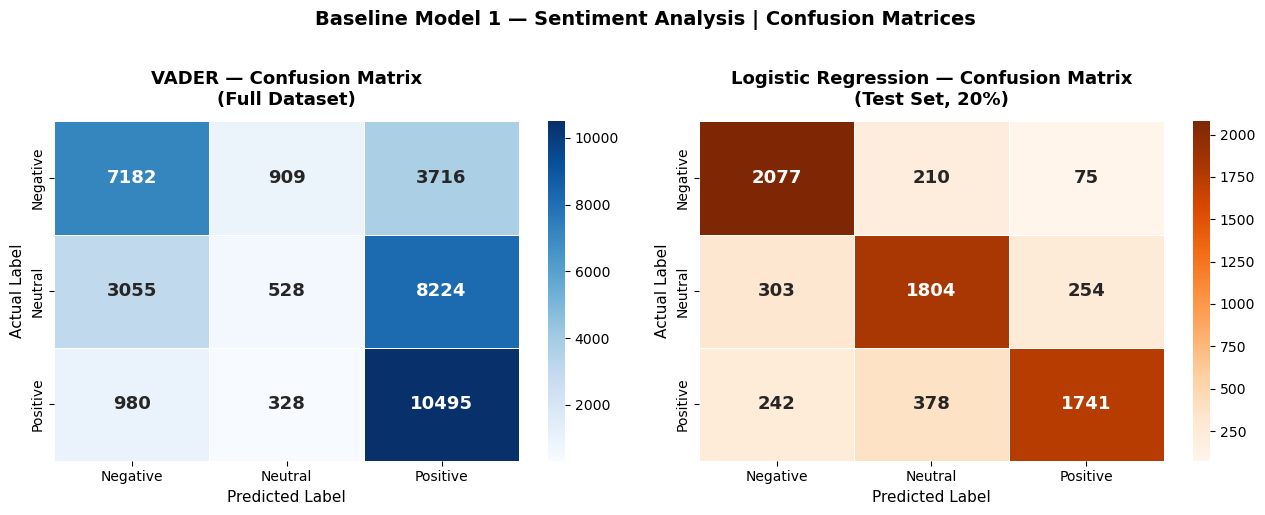

  [SAVED] Confusion matrices chart saved to: model1_confusion_matrices.png


In [31]:
# Save anonymized dataset (without original comments)
anonymized_path = "anonymized_edufeed_model1.csv"
df.to_csv(anonymized_path, index=False)
print(f"  [SAVED] Anonymized dataset saved to: {anonymized_path}")
 
# Save accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(7, 5))
models  = ["VADER\n(Rule-Based)", "Logistic Regression\n(TF-IDF, n-gram 1-2)"]
scores  = [vader_acc * 100, lr_acc * 100]
colors  = ["#5B8DB8", "#E8734A"]
bars    = ax.bar(models, scores, color=colors, width=0.45, edgecolor="black", linewidth=0.8)
 
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{score:.2f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
 
ax.set_ylim(0, 100)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Baseline Model 1 — Sentiment Analysis\nAccuracy Comparison", fontsize=13, fontweight="bold")
ax.axhline(y=65, color="gray", linestyle="--", linewidth=0.9, label="Expected ceiling (65%)")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
 
chart_path = "model1_sentiment_accuracy_comparison.png"
plt.savefig(chart_path, dpi=150)
plt.close()
print(f"  [SAVED] Accuracy comparison chart saved to: {chart_path}")
 
# ── Confusion Matrix Plots (side by side) ────────────────────────────────────
LABELS = sorted(y.unique())   # consistent label order across both matrices
 
# Recompute matrices with consistent label order
vader_cm_plot = confusion_matrix(y,      vader_preds, labels=LABELS)
lr_cm_plot    = confusion_matrix(y_test, lr_preds,    labels=LABELS)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
def plot_cm(ax, cm, labels, title, cmap):
    """Helper to draw a labelled heatmap confusion matrix."""
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"}
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label",    fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
 
plot_cm(axes[0], vader_cm_plot, LABELS,
        "VADER — Confusion Matrix\n(Full Dataset)", "Blues")
 
plot_cm(axes[1], lr_cm_plot, LABELS,
        "Logistic Regression — Confusion Matrix\n(Test Set, 20%)", "Oranges")
 
plt.suptitle("Baseline Model 1 — Sentiment Analysis | Confusion Matrices",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
display(fig)
 
cm_path = "model1_confusion_matrices.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.close()
print(f"  [SAVED] Confusion matrices chart saved to: {cm_path}")
 